In [3]:
import os
os.getcwd()

'/Users/tj/Downloads/AI/DL/CNN_selfprojects/face_mask'

In [69]:
from PIL import Image
import os

bad_files = []
for folder in ["dataset/data/with_mask", "dataset/data/without_mask"]:
    print("Checking", folder)
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            img = Image.open(path)
            img.verify()
        except Exception as e:
            bad_files.append(path)

for f in bad_files:
    os.remove(f)
print("Removed", len(bad_files), "corrupt files")

# Also remove empty files
removed = 0
for folder in ["dataset/data/with_mask", "dataset/data/without_mask"]:
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            if os.path.getsize(path) == 0:
                os.remove(path)
                removed += 1
        except:
            pass
print("Removed", removed, "empty files")

Checking dataset/data/with_mask
Checking dataset/data/without_mask
Removed 0 corrupt files
Removed 0 empty files


In [12]:
import matplotlib as plt
def plot_images(dir):
    fig,axis=plt.subplots(1,5,fig_size=(20,20))
    axis=axis.flatten()
    for img,ax in zip(dir,axis):
        ax.imshow(img)
    plt.tighlayout()
    plt.show()


In [70]:
import tensorflow as tf
from tensorflow import keras

IMG_SIZE = (200, 200)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = keras.utils.image_dataset_from_directory(
    "dataset/data",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    "dataset/data",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds   = val_ds.apply(tf.data.experimental.ignore_errors())

Found 7645 files belonging to 2 classes.
Using 6116 files for training.
Found 7645 files belonging to 2 classes.
Using 1529 files for validation.
Classes: ['with_mask', 'without_mask']


In [71]:
from tensorflow.keras import layers

# Data augmentation pipeline (applied only during training)
data_augmentation = keras.Sequential([
    layers.RandomFlip(mode="horizontal"),
    layers.RandomRotation(0.05),             
    layers.RandomZoom(0.1),                 
    layers.RandomTranslation(0.1, 0.1),      
    layers.RandomContrast(0.2),              
    layers.RandomBrightness(0.2),            
], name="augmentation")



def preprocess(image, label):
    # 1. Convert the image to float32 (required before division)
    image = tf.cast(image, tf.float32)
    
    image =image/255.0
    
    return image, label

# Apply augmentation + preprocess to train, only preprocess to val
train_ds = (
    train_ds
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

print("Pipeline ready!")

Pipeline ready!


In [32]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout,GlobalAveragePooling2D
import matplotlib.pyplot as plt
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(200,200,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))


model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())

model.add(Conv2D(256,(3,3),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.3))

model.add(GlobalAveragePooling2D())

model.add(Dense(512,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(2,activation='softmax'))

model.summary()

/opt/anaconda3/envs/deepenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 587,842 (2.24 MB)

 Trainable params: 586,882 (2.24 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)


Training phase
Epoch 1/20
    189/Unknown 108s 563ms/step - accuracy: 0.7138 - loss: 0.5911

/opt/anaconda3/envs/deepenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


189/189 ━━━━━━━━━━━━━━━━━━━━ 114s 595ms/step - accuracy: 0.7409 - loss: 0.5493 - val_accuracy: 0.7629 - val_loss: 0.5057 - learning_rate: 0.0010
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 123s 652ms/step - accuracy: 0.8352 - loss: 0.3812 - val_accuracy: 0.8788 - val_loss: 0.2887 - learning_rate: 0.0010
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 132s 698ms/step - accuracy: 0.9068 - loss: 0.2442 - val_accuracy: 0.8755 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 135s 714ms/step - accuracy: 0.9355 - loss: 0.1776 - val_accuracy: 0.9159 - val_loss: 0.2183 - learning_rate: 0.0010
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 138s 732ms/step - accuracy: 0.9499 - loss: 0.1437 - val_accuracy: 0.9172 - val_loss: 0.2010 - learning_rate: 0.0010
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 144s 763ms/step - accuracy: 0.9528 - loss: 0.1243 - val_accuracy: 0.9126 - val_loss: 0.2212 - learning_rate: 0.0010
Epoch 7/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 146s 775ms/step - accuracy: 0.9575 

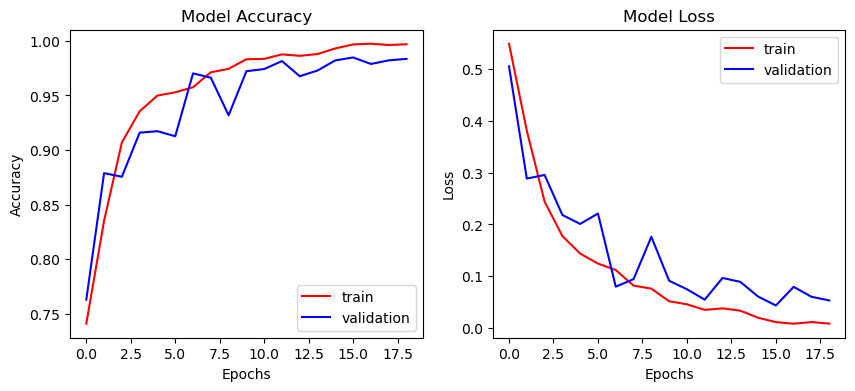

In [19]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], color='red', label='train')
plt.plot(history1.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], color='red', label='train')
plt.plot(history1.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
loss, accuracy = model.evaluate(val_ds, verbose=1)
print(f"\nFinal Validation Loss:     {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9848 - loss: 0.0434

Final Validation Loss:     0.0434
Final Validation Accuracy: 0.9848 (98.48%)


/opt/anaconda3/envs/deepenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [21]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


In [3]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def predict_mask(image_path, trained_model):
    """
    Predicts if an image has a mask or not, writes the result directly 
    onto the image, and displays it inline in the notebook.
    """
    # ---------------------------------------------------------
    # 1. MAKE THE PREDICTION (Using the 200x200 scaled image)
    # ---------------------------------------------------------
    img_pred = tf.keras.utils.load_img(image_path, target_size=(200, 200))
    img_array = tf.keras.utils.img_to_array(img_pred) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    predictions = trained_model.predict(img_array, verbose=0)
    predicted_class_index = np.argmax(predictions, axis=-1)[0]
    confidence_score = np.max(predictions)
    
    class_names = ['with_mask', 'without_mask'] 
    final_prediction = class_names[predicted_class_index]
    
    # ---------------------------------------------------------
    # 2. DRAW ON THE IMAGE (Using the original, unscaled image)
    # ---------------------------------------------------------
    # Read the image using OpenCV
    img_display = cv2.imread(image_path)
    
    # OpenCV loads images in BGR format, but Matplotlib uses RGB. We must convert it.
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    
    # Create the text string to display
    text = f"{final_prediction}: {confidence_score*100:.1f}%"
    
    # Choose a color: Green for 'with_mask', Red for 'without_mask'
    # Colors in RGB format
    if final_prediction == 'with_mask':
        color = (0, 255, 0)  # Green
    else:
        color = (255, 0, 0)  # Red
        
    # Draw the text onto the image array
    # Parameters: image, text, coordinates (x, y), font, font_scale, color, thickness
    cv2.putText(img_display, text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)
    
    # ---------------------------------------------------------
    # 3. DISPLAY THE RESULT
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 8))
    plt.imshow(img_display)
    plt.axis('off') # Hides the axes and gridlines
    plt.show()
    return final_prediction, confidence_score

# --- How to use it ---
# predict_and_visualize('path/to/your/test/image.jpg', model)

# --- How to use it ---
# result, confidence = predict_mask('2.jpg', model)

In [2]:
# import tensorflow as tf
# model = tf.keras.models.load_model('1st_try.keras')
# result, confidence = predict_mask('2.jpg', model)

In [9]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)


Training phase
Epoch 1/20
    189/Unknown 115s 600ms/step - accuracy: 0.9488 - loss: 0.1519

/opt/anaconda3/envs/deepenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


189/189 ━━━━━━━━━━━━━━━━━━━━ 121s 632ms/step - accuracy: 0.9555 - loss: 0.1262 - val_accuracy: 0.5086 - val_loss: 0.8127 - learning_rate: 0.0010
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 133s 703ms/step - accuracy: 0.9674 - loss: 0.0856 - val_accuracy: 0.5086 - val_loss: 1.2647 - learning_rate: 0.0010
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9732 - loss: 0.0690
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
189/189 ━━━━━━━━━━━━━━━━━━━━ 154s 813ms/step - accuracy: 0.9767 - loss: 0.0648 - val_accuracy: 0.5086 - val_loss: 1.7336 - learning_rate: 0.0010
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 152s 805ms/step - accuracy: 0.9831 - loss: 0.0446 - val_accuracy: 0.6285 - val_loss: 0.7813 - learning_rate: 5.0000e-04
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 151s 800ms/step - accuracy: 0.9887 - loss: 0.0304 - val_accuracy: 0.8351 - val_loss: 0.4690 - learning_rate: 5.0000e-04
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 167s 881ms/step - accuracy: 0.

In [10]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


In [11]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)


Training phase
Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 122s 638ms/step - accuracy: 0.9863 - loss: 0.0402 - val_accuracy: 0.9742 - val_loss: 0.0905 - learning_rate: 0.0010
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 154s 815ms/step - accuracy: 0.9878 - loss: 0.0313 - val_accuracy: 0.9483 - val_loss: 0.2150 - learning_rate: 0.0010
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.9853 - loss: 0.0331
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
189/189 ━━━━━━━━━━━━━━━━━━━━ 153s 809ms/step - accuracy: 0.9861 - loss: 0.0326 - val_accuracy: 0.9728 - val_loss: 0.1090 - learning_rate: 0.0010
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 162s 857ms/step - accuracy: 0.9959 - loss: 0.0106 - val_accuracy: 0.9649 - val_loss: 0.1555 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


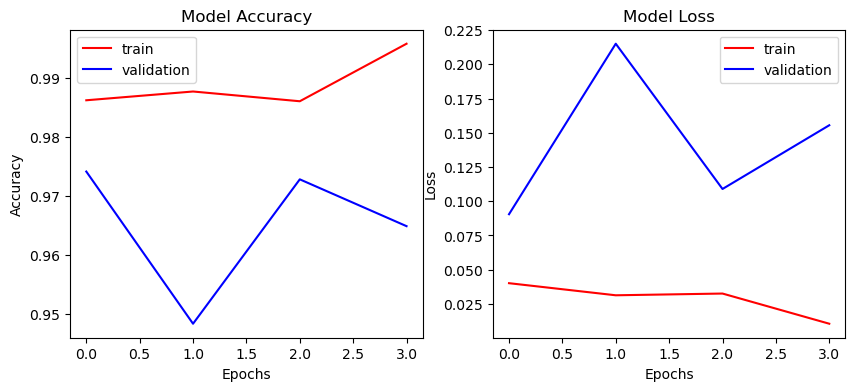

In [12]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], color='red', label='train')
plt.plot(history1.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], color='red', label='train')
plt.plot(history1.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


In [15]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Training phase
Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 114s 595ms/step - accuracy: 0.9831 - loss: 0.0478 - val_accuracy: 0.9629 - val_loss: 0.1254 - learning_rate: 0.0010
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 120s 633ms/step - accuracy: 0.9831 - loss: 0.0477 - val_accuracy: 0.8808 - val_loss: 0.4484 - learning_rate: 0.0010
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.9897 - loss: 0.0317
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
189/189 ━━━━━━━━━━━━━━━━━━━━ 150s 792ms/step - accuracy: 0.9891 - loss: 0.0337 - val_accuracy: 0.8589 - val_loss: 0.9662 - learning_rate: 0.0010
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 143s 754ms/step - accuracy: 0.9945 - loss: 0.0186 - val_accuracy: 0.9675 - val_loss: 0.1087 - learning_rate: 5.0000e-04
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 141s 744ms/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 0.9795 - val_loss: 0.0850 - learning_rate: 5.0000e-04
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 143s

In [16]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


In [1]:
# import tensorflow as tf
# model = tf.keras.models.load_model('1st_try.keras')
# result, confidence = predict_mask('2.jpg', model)

In [25]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Training phase
Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 187s 987ms/step - accuracy: 0.9892 - loss: 0.0325 - val_accuracy: 0.9623 - val_loss: 0.1914 - learning_rate: 0.0010
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9909 - loss: 0.0236 - val_accuracy: 0.9609 - val_loss: 0.1342 - learning_rate: 0.0010
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9912 - loss: 0.0271 - val_accuracy: 0.9808 - val_loss: 0.0819 - learning_rate: 0.0010
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9969 - loss: 0.0121 - val_accuracy: 0.9735 - val_loss: 0.1308 - learning_rate: 0.0010
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.9822 - loss: 0.0549
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
189/189 ━━━━━━━━━━━━━━━━━━━━ 142s 752ms/step - accuracy: 0.9836 - loss: 0.0499 - val_accuracy: 0.9682 - val_loss: 0.1226 - learning_rate: 0.0010
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 139s 734ms/step - acc

In [27]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


In [3]:
# import tensorflow as tf
# model = tf.keras.models.load_model('1st_try.keras')
# # result, confidence = predict_mask('m.jpg', model)

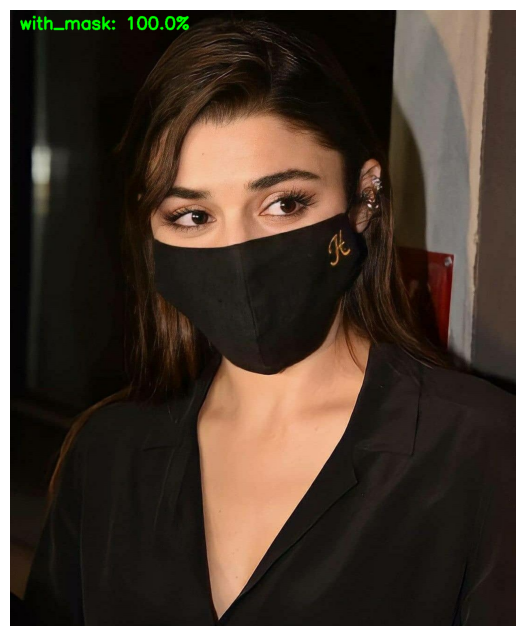

In [40]:
import tensorflow as tf
model = tf.keras.models.load_model('1st_try.keras')
result, confidence = predict_mask('hayat1.jpg', model)

In [41]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Training phase
Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 119s 616ms/step - accuracy: 0.9722 - loss: 0.0818 - val_accuracy: 0.9213 - val_loss: 0.3273 - learning_rate: 0.0010
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 151s 795ms/step - accuracy: 0.9794 - loss: 0.0570 - val_accuracy: 0.9489 - val_loss: 0.1410 - learning_rate: 0.0010
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 157s 828ms/step - accuracy: 0.9873 - loss: 0.0349 - val_accuracy: 0.9816 - val_loss: 0.0666 - learning_rate: 0.0010
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 167s 878ms/step - accuracy: 0.9855 - loss: 0.0418 - val_accuracy: 0.9718 - val_loss: 0.0995 - learning_rate: 0.0010
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.9868 - loss: 0.0346
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
190/190 ━━━━━━━━━━━━━━━━━━━━ 170s 894ms/step - accuracy: 0.9852 - loss: 0.0411 - val_accuracy: 0.9200 - val_loss: 0.3915 - learning_rate: 0.0010
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 176s 926ms/s

In [42]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


In [4]:
# import tensorflow as tf
# model = tf.keras.models.load_model('1st_try.keras')
# result, confidence = predict_mask('bachi2.jpg', model)

In [56]:
import tensorflow as tf
model = tf.keras.models.load_model('1st_try.keras')

In [57]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Training phase
Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 115s 599ms/step - accuracy: 0.9875 - loss: 0.0455 - val_accuracy: 0.9757 - val_loss: 0.0743 - learning_rate: 0.0010
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 138s 724ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9823 - val_loss: 0.0748 - learning_rate: 0.0010
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.9929 - loss: 0.0218
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
190/190 ━━━━━━━━━━━━━━━━━━━━ 148s 777ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9777 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 157s 827ms/step - accuracy: 0.9964 - loss: 0.0106 - val_accuracy: 0.9810 - val_loss: 0.0771 - learning_rate: 5.0000e-04
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 157s 825ms/step - accuracy: 0.9982 - loss: 0.0053 - val_accuracy: 0.9875 - val_loss: 0.0639 - learning_rate: 5.0000e-04
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 166s

In [58]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


In [5]:
# import tensorflow as tf
# model = tf.keras.models.load_model('1st_try.keras')
# result, confidence = predict_mask('bachi2.jpg', model)

In [6]:
# import tensorflow as tf
# model = tf.keras.models.load_model('1st_try.keras')
# result, confidence = predict_mask('m.jpg', model)

In [72]:
import tensorflow as tf
model = tf.keras.models.load_model('1st_try.keras')

# result, confidence = predict_mask('c.jpg', model)

In [73]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Training phase
Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 112s 584ms/step - accuracy: 0.9736 - loss: 0.0778 - val_accuracy: 0.9673 - val_loss: 0.0854 - learning_rate: 0.0010
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 117s 616ms/step - accuracy: 0.9795 - loss: 0.0523 - val_accuracy: 0.9791 - val_loss: 0.0808 - learning_rate: 0.0010
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 131s 689ms/step - accuracy: 0.9856 - loss: 0.0366 - val_accuracy: 0.9581 - val_loss: 0.1185 - learning_rate: 0.0010
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.9864 - loss: 0.0339
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
190/190 ━━━━━━━━━━━━━━━━━━━━ 130s 683ms/step - accuracy: 0.9856 - loss: 0.0371 - val_accuracy: 0.9771 - val_loss: 0.0947 - learning_rate: 0.0010
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 133s 701ms/step - accuracy: 0.9929 - loss: 0.0189 - val_accuracy: 0.9765 - val_loss: 0.0759 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights 

In [74]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Training phase
Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 112s 584ms/step - accuracy: 0.9840 - loss: 0.0447 - val_accuracy: 0.9810 - val_loss: 0.0616 - learning_rate: 0.0010
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 126s 664ms/step - accuracy: 0.9874 - loss: 0.0346 - val_accuracy: 0.9758 - val_loss: 0.0961 - learning_rate: 0.0010
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.9887 - loss: 0.0322
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
190/190 ━━━━━━━━━━━━━━━━━━━━ 137s 722ms/step - accuracy: 0.9888 - loss: 0.0368 - val_accuracy: 0.9052 - val_loss: 0.2910 - learning_rate: 0.0010
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 136s 717ms/step - accuracy: 0.9917 - loss: 0.0219 - val_accuracy: 0.9876 - val_loss: 0.0374 - learning_rate: 5.0000e-04
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 142s 748ms/step - accuracy: 0.9964 - loss: 0.0104 - val_accuracy: 0.9882 - val_loss: 0.0508 - learning_rate: 5.0000e-04
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 6

In [75]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


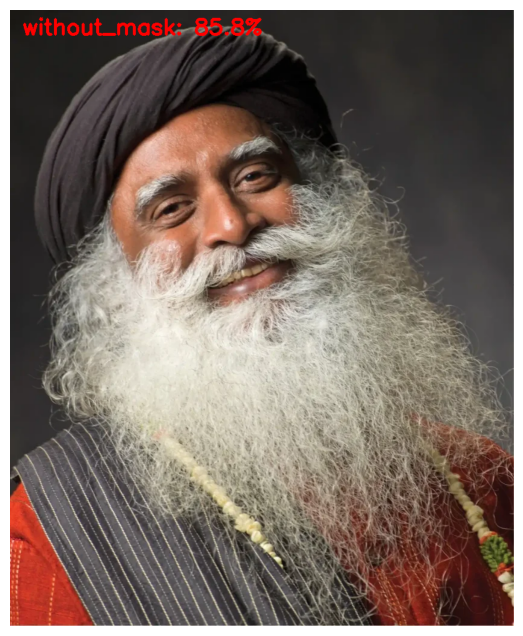

In [78]:
import tensorflow as tf
model = tf.keras.models.load_model('1st_try.keras')
result, confidence = predict_mask('sad.jpg', model)

In [79]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]
print('Training phase')
history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Training phase
Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 113s 586ms/step - accuracy: 0.9889 - loss: 0.0358 - val_accuracy: 0.9680 - val_loss: 0.1079 - learning_rate: 0.0010
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 118s 620ms/step - accuracy: 0.9955 - loss: 0.0128 - val_accuracy: 0.9778 - val_loss: 0.0961 - learning_rate: 0.0010
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 130s 682ms/step - accuracy: 0.9922 - loss: 0.0211 - val_accuracy: 0.9719 - val_loss: 0.0934 - learning_rate: 0.0010
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 131s 689ms/step - accuracy: 0.9924 - loss: 0.0250 - val_accuracy: 0.9248 - val_loss: 0.4769 - learning_rate: 0.0010
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.9911 - loss: 0.0228
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
190/190 ━━━━━━━━━━━━━━━━━━━━ 134s 705ms/step - accuracy: 0.9931 - loss: 0.0186 - val_accuracy: 0.9640 - val_loss: 0.1732 - learning_rate: 0.0010
Epoch 5: early stopping
Restoring model weights from

In [80]:
model.save("1st_try.keras")
print("Model saved as 1st_try.keras")

Model saved as 1st_try.keras


In [7]:
# import tensorflow as tf
# model = tf.keras.models.load_model('1st_try.keras')
# result, confidence = predict_mask('m.jpg', model)